# 02 弧长表与进给波动

数控插补器每个插补周期（interpolation period，$T_s$，通常 1 ms）都要回答一个问题：刀具此刻应该在哪里？
指令进给速度 $v$ 是沿**弧长**的（mm/s），而曲线 $\mathbf{C}(u)$ 按**参数** $u$ 求值。
把"时间"翻译成"参数"，中间隔着一条弧长函数 $s(u)$。这本 notebook 讲清楚这一步怎么做、误差有多大。

**本节回答的问题：**

1. 为什么插补必须知道弧长？$\sigma(u)=\lVert\mathbf{C}'(u)\rVert$ 为什么一般不是常数？
2. 弧长积分 $s(u)=\int\sigma\,\mathrm{d}u$ 没有闭式解，怎么数值求、误差如何控制（自适应弧长表 `ArcLengthTable`）？
3. 经典的参数插补（Taylor 展开推进 $u$）为什么会让进给速度波动？一阶、二阶差多少？
4. 弧长表插补与进给修正多项式（feed correction）又能精确到什么程度？
5. 用弦长测进给波动时，这个指标本身的测量下限是多少？

**前置知识：** notebook 01 的曲线接口与导数栈约定（`curve(u, k)`、`curve.derivatives(u)`，形状 `(4, ..., dim)`）。

In [1]:
import os.path as osp
import sys
from pathlib import Path

import matplotlib.pyplot as plt

root_path = Path(osp.abspath("")).parents[0]
sys.path.append(str(root_path))

%config InlineBackend.figure_format='retina'

In [2]:
import numpy as np

import cnc5x as cx
from cnc5x import plotting

plotting.use_style()

## 1. 问题：进给沿弧长，曲线按参数

理想的插补是：第 $k$ 个周期走到弧长 $s_k=k\,vT_s$ 处，即求 $\mathbf{C}(u(s_k))$。
但参数 $u$ 与弧长 $s$ 的关系由**速度**（speed）

$$
\sigma(u)=\frac{\mathrm{d}s}{\mathrm{d}u}=\lVert\mathbf{C}'(u)\rVert
$$

决定。只有直线和圆的标准参数化才有 $\sigma\equiv$ 常数；一般的 B 样条 $\sigma(u)$ 随 $u$ 大幅起伏。
参数走同样的步长 $\Delta u$，刀具实际走过的弧长 $\sigma\Delta u$ 忽长忽短——进给速度就波动了。

用后面的算例曲线看一眼：一条 6 控制点的三次 B 样条（与 `tests/test_interpolator.py` 同一条）。

σ 的范围：54.6 ~ 242.3 mm（比值 4.4）
曲线总长：88.8811 mm


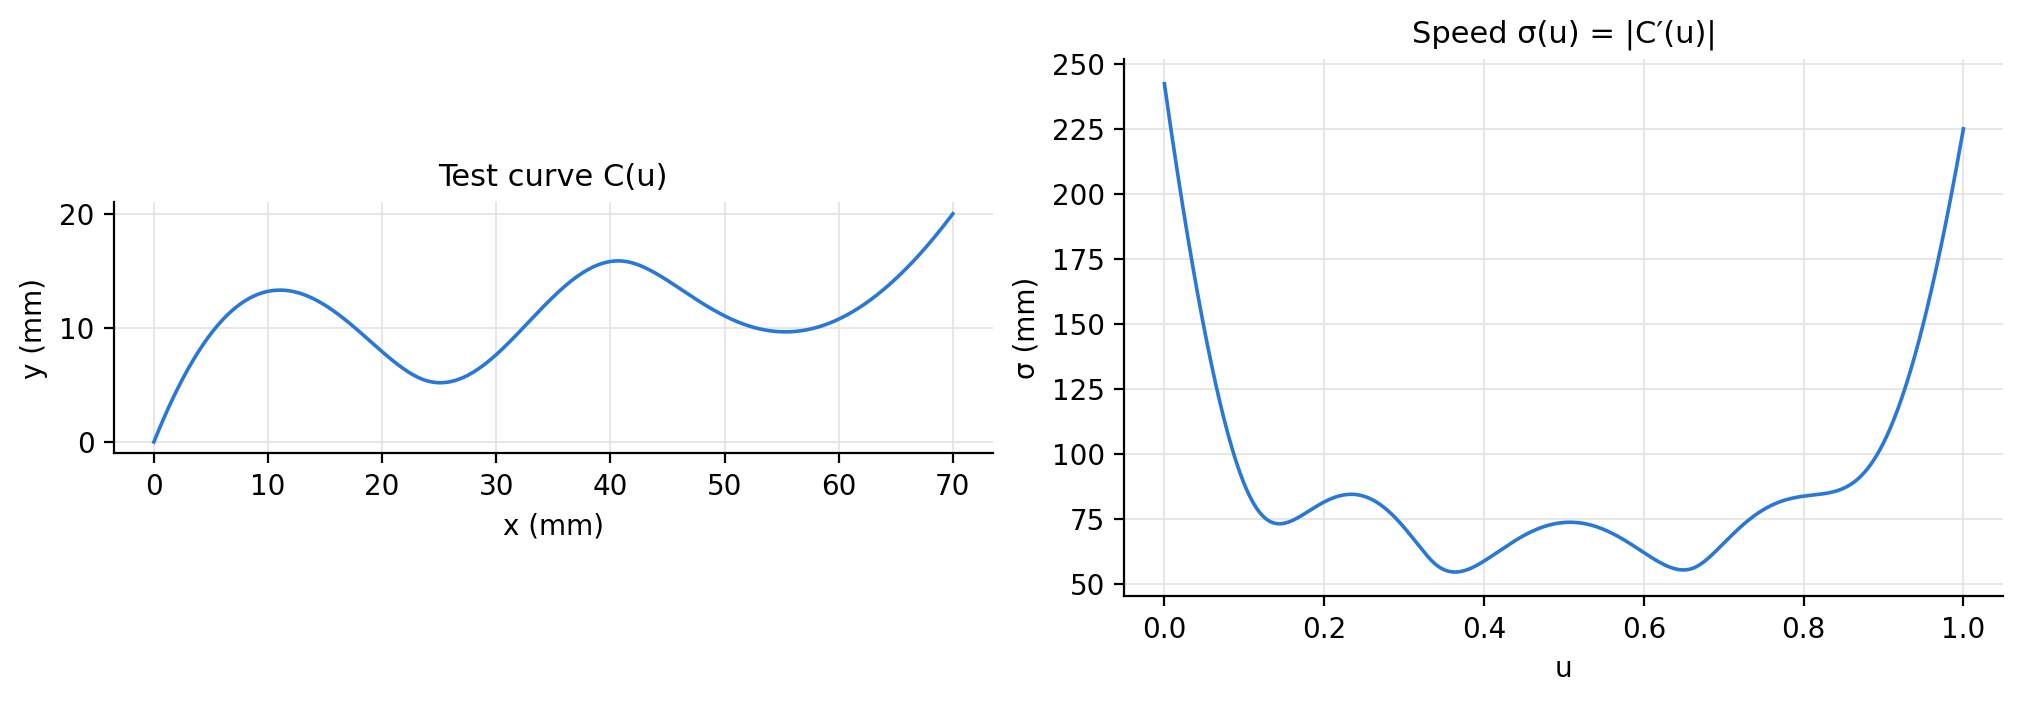

In [3]:
# 全文共用的算例：控制点 zigzag 的三次 B 样条，σ 起伏明显
CURVE = cx.BSpline([[0, 0], [10, 25], [25, -10], [40, 30], [55, 0], [70, 20]], 3)
u_dense = np.linspace(*CURVE.domain, 800)
sigma = CURVE.speed(u_dense)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].plot(*CURVE(u_dense).T, color=plotting.COLORS[0])
axes[0].set_aspect("equal")
axes[0].set(xlabel="x (mm)", ylabel="y (mm)", title="Test curve C(u)")
axes[1].plot(u_dense, sigma, color=plotting.COLORS[0])
axes[1].set(xlabel="u", ylabel="σ (mm)", title="Speed σ(u) = |C′(u)|")
print(f"σ 的范围：{sigma.min():.1f} ~ {sigma.max():.1f} mm（比值 {sigma.max() / sigma.min():.1f}）")
print(f"曲线总长：{CURVE.length:.4f} mm")

同一个 $\Delta u$，在 $\sigma$ 大处走过的路程是 $\sigma$ 小处的近 5 倍。
若插补器假装 $\sigma$ 是常数来推进 $u$，进给误差就是这个量级——这正是第 5 节要定量看的现象。

**要点：** 指令进给是对弧长 $s$ 的，曲线求值是对参数 $u$ 的；中间的翻译官是 $\sigma(u)=\lVert\mathbf{C}'(u)\rVert$。

## 2. 弧长积分：Gauss–Legendre 求积

弧长是 $\sigma$ 的积分：

$$
s(u)=\int_{u_0}^{u}\lVert\mathbf{C}'(\xi)\rVert\,\mathrm{d}\xi .
$$

被积函数里有平方和开根号，即使 $\mathbf{C}(u)$ 是多项式，这个积分一般也没有闭式解（椭圆积分），只能数值求。
$cnc5x$ 用 **Gauss–Legendre 求积**：把区间映到 $[-1,1]$，在 8 个特定节点 $x_i$ 上采样被积函数，加权和

$$
\int_a^b f(\xi)\,\mathrm{d}\xi\approx\frac{b-a}{2}\sum_{i=1}^{8}w_i\,f\!\left(\tfrac{a+b}{2}+\tfrac{b-a}{2}x_i\right) .
$$

节点与权重来自 Legendre 多项式的零点，是成熟的数值内核：库直接取 `numpy.polynomial.legendre.leggauss(8)`，
**不自己实现**（CLAUDE.md 第 5 节的原则：节点权重不承载论文的算法思想）。8 点对 15 次以内的多项式精确。

先白盒写一遍，再和 `scipy.integrate.quad` 对照：

In [4]:
# 白盒：8 点 Gauss–Legendre 求 σ 在一个 knot 跨度上的积分（整段 + 两个半段）
from scipy.integrate import quad

X, W = np.polynomial.legendre.leggauss(8)


def gauss8(f, a, b):
    nodes = (a + b) / 2 + (b - a) / 2 * X
    return (b - a) / 2 * (f(nodes) @ W)


a, b = 0.25, 1 / 3  # 一个完整多项式跨度的四分之一（即弧长表的起始小段），不跨过节点
m = (a + b) / 2
whole = gauss8(CURVE.speed, a, b)
two_halves = gauss8(CURVE.speed, a, m) + gauss8(CURVE.speed, m, b)

reference = quad(CURVE.speed, a, b, epsabs=1e-14)[0]
print(f"整段 8 点 Gauss：{whole:.12f}")
print(f"两半 8 点 Gauss：{two_halves:.12f}（弧长表取这个值）")
print(f"quad 参考：      {reference:.12f}")
print(f"整段与两半之差：{abs(whole - two_halves):.3e}（弧长表的积分误差估计）")
print(f"两半与 quad 之差：{abs(two_halves - reference):.3e}")
assert abs(two_halves - reference) < 1e-12

整段 8 点 Gauss：6.121079427198
两半 8 点 Gauss：6.121079427210（弧长表取这个值）
quad 参考：      6.121079427210
整段与两半之差：1.229e-11（弧长表的积分误差估计）
两半与 quad 之差：8.882e-16


In [5]:
# 对照实验：跨过节点 u=1/3 的区间，σ 在节点处不光滑，同样的求积误差大几个数量级
c, d = 0.2, 0.47  # 跨过节点 1/3，与上面的小段等长
whole_x = gauss8(CURVE.speed, c, d)
m_x = (c + d) / 2
halves_x = gauss8(CURVE.speed, c, m_x) + gauss8(CURVE.speed, m_x, d)
ref_x = quad(CURVE.speed, c, d, points=[1 / 3], epsabs=1e-14)[0]  # quad 也提示它在节点处分开
print(f"等长的跨节点区间 [{c}, {d}]：")
print(f"整段误差 {abs(whole_x - ref_x):.3e}，两半误差 {abs(halves_x - ref_x):.3e}")
print("── 这就是弧长表的起始网格先在 breaks 处分开的原因")

等长的跨节点区间 [0.2, 0.47]：
整段误差 5.040e-03，两半误差 3.451e-06
── 这就是弧长表的起始网格先在 breaks 处分开的原因


两格合起来说明三件事：

1. 在多项式跨度内部，8 点 Gauss 已经准到舍入量级（与 quad 的差在 $10^{-12}$ 以下）；
2. **整段与两半之差**是免费的误差估计：求积误差随区间长度高次下降，两半各算一次再相加
   比整段准得多，两者之差就近似是整段那次的误差——弧长表把它作为三个误差估计的第一个；
3. 跨过样条节点时 $\sigma$ 不光滑，同样的算法在等长区间上误差大几个数量级——
   所以起始网格先在 `breaks` 处分开。

**要点：** 弧长积分没有闭式解；8 点 Gauss–Legendre 在每个小段上求值，"整段 vs 两半"自带误差估计，
不光滑点必须单独断开。

## 3. 自适应弧长表 `ArcLengthTable`

插补时要反复求 $s(u)$ 和反函数 $u(s)$，每次都做自适应积分太贵。弧长表的做法：
**一次建表，之后全是 Hermite 插值查询**。

建表流程（`curves.py`，与 docs/数学约定.md 第 2 节一致）：

1. **起始网格**：先在 `breaks`（样条节点，$\sigma$ 可能不光滑）处分开——跨过不光滑点的积分收敛很慢；
   每个节点区间再四等分。为什么四等分：只在中点检查插值误差会漏掉关于自身中点对称的段
   （那种段的误差恰好在中点为零），四等分后每个小段一般不再对称。
2. **每一小段 $[a,b]$**（中点 $m$）做三次 8 点 Gauss（整段、左半、右半），弧长取两半之和。
3. **三个误差估计**，单位都是长度（mm）：
   - 积分误差：$\lvert I_{\text{整}}-(I_{\text{左}}+I_{\text{右}})\rvert$；
   - $s(u)$ 的插值误差：段内 $s(u)$ 用三次 Hermite（端点值 $s_a,s_b$、端点斜率 $\sigma_a,\sigma_b$）表示，
     比较它在 $m$ 处的值与积分真值 $s(m)=I_{\text{左}}$；
   - $u(s)$ 的插值误差：反方向 Hermite（端点斜率 $1/\sigma$）在 $s(m)$ 处给出参数 $\tilde m$，
     把 $\lvert\tilde m - m\rvert$ 乘 $\sigma(m)$ 换算成长度。
4. 三者最大值超过容差 `tolerances.ARC_LENGTH`（$10^{-8}$ mm，比有物理意义的长度小 5 个数量级）的段对半分，
   回到第 2 步，直到全部达标（最多 40 层）。

段内的 $s(u)$、$u(s)$ 都用 `scipy.interpolate.CubicHermiteSpline` 拼成整体。三次 Hermite 的误差与段长的
**四次方**成正比，所以容差每缩小 10 倍，段数只增加约 $10^{1/4}\approx1.8$ 倍（第 4 节会验证）。

分段数：715（容差 1e-08 mm）
总弧长：88.881067 mm


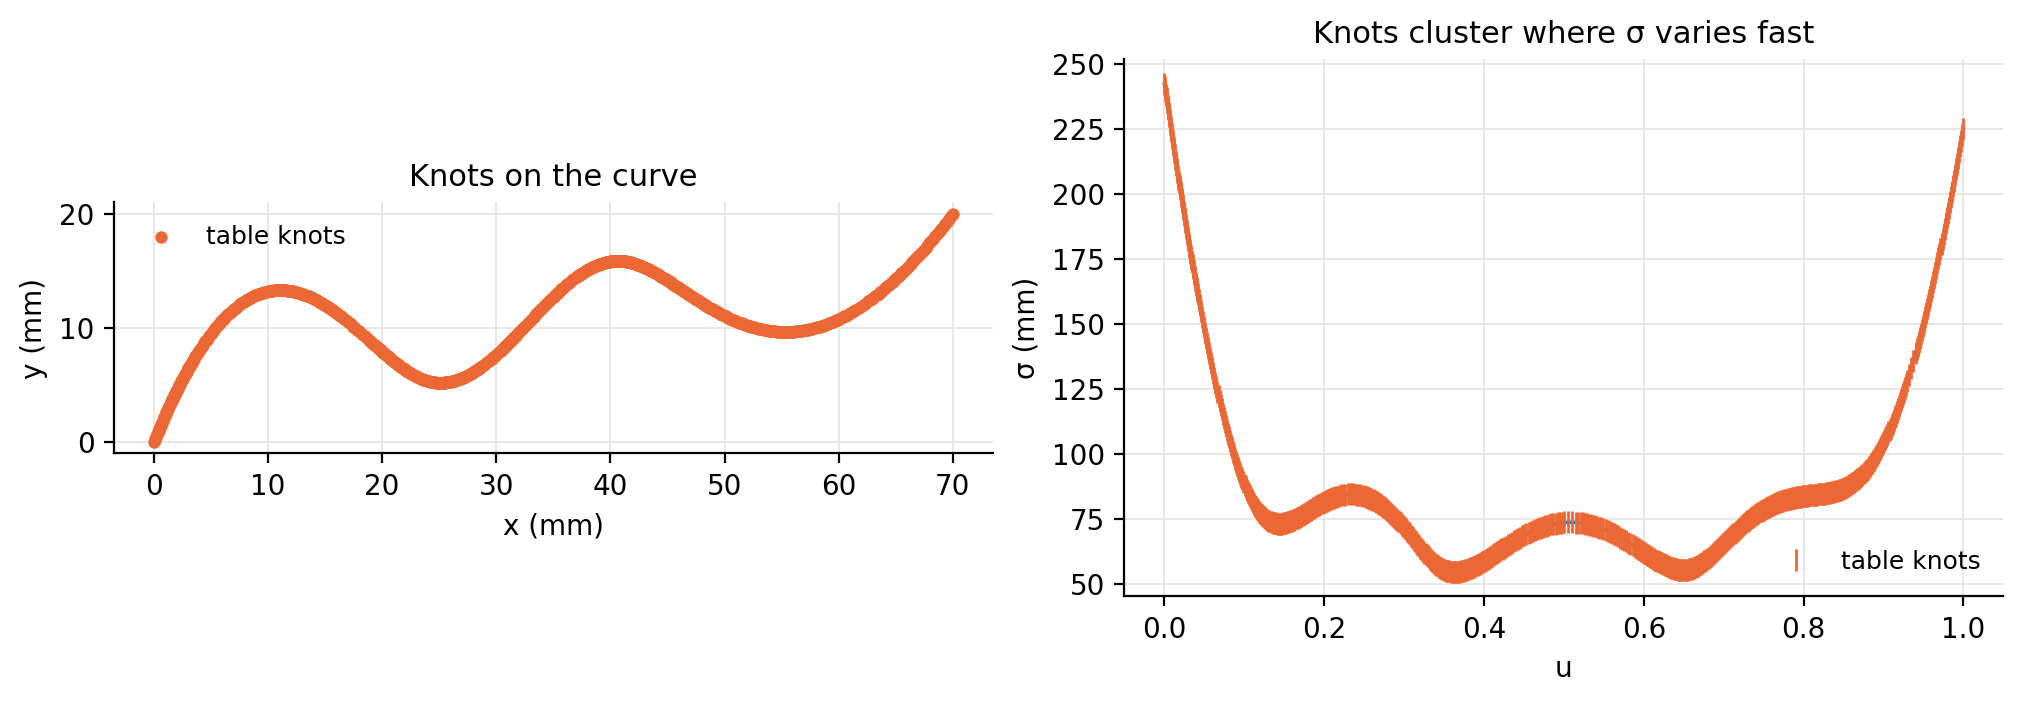

In [6]:
from cnc5x.curves import ArcLengthTable

arc = CURVE.arc  # cached_property：第一次用到时才建表
print(f"分段数：{len(arc.u_grid) - 1}（容差 {cx.tolerances.ARC_LENGTH:.0e} mm）")
print(f"总弧长：{arc.total:.6f} mm")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].plot(*CURVE(u_dense).T, color=plotting.COLORS[0], zorder=1)
axes[0].scatter(*CURVE(arc.u_grid).T, s=12, color=plotting.COLORS[1], zorder=2, label="table knots")
axes[0].set_aspect("equal")
axes[0].set(xlabel="x (mm)", ylabel="y (mm)", title="Knots on the curve")
axes[0].legend()
axes[1].plot(u_dense, sigma, color=plotting.COLORS[0])
axes[1].plot(arc.u_grid, CURVE.speed(arc.u_grid), "|", color=plotting.COLORS[1], ms=8, label="table knots")
axes[1].set(xlabel="u", ylabel="σ (mm)", title="Knots cluster where σ varies fast")
axes[1].legend(loc="lower right")

右图横轴上的刻度是表的分段点：$\sigma$ 变化平缓的中段分得粗，两端 $\sigma$ 剧烈起伏处自动加密——
这就是"自适应"的含义：分段密度由误差决定，而不是事先拍一个固定段数。
（docs 里提到：在点距相差上千倍的插值样条上，旧的"固定 256 段"做法误差可达毫米量级，
见 `tests/test_curves.py` 的 `test_arc_length_table_on_uneven_spline`。）

查表：`curve.length_at(u)` 即 $s(u)$，`curve.u_at_length(s)` 即反函数 $u(s)$。

In [7]:
# 查表演示：s(u) 与 u(s) 互为反函数
u_try = np.array([0.1, 0.35, 0.7, 0.95])
s_try = CURVE.length_at(u_try)
u_back = CURVE.u_at_length(s_try)
print("u      ->  s(u) (mm) ->  u(s(u))")
for u0, s0, u1 in zip(u_try, s_try, u_back):
    print(f"{u0:.2f}  ->  {s0:9.5f}  ->  {u1:.10f}")
assert np.allclose(u_back, u_try, atol=1e-9)

u      ->  s(u) (mm) ->  u(s(u))
0.10  ->   15.36119  ->  0.1000000000
0.35  ->   34.33876  ->  0.3500000000
0.70  ->   56.73868  ->  0.7000000000
0.95  ->   79.61114  ->  0.9500000000


**要点：** 弧长表 = Gauss 积分定端点 + 三次 Hermite 填段内，三种误差估计（积分、$s(u)$ 插值、$u(s)$ 插值）
一起受 `tolerances.ARC_LENGTH` 控制，不合格就二分；$\sigma$ 变化剧烈处自动加密。

## 4. 精度检验：误差跟随容差

建表时用误差估计决定分段，那只是**估计**。现在用独立参考值实测：

- $s(u)$ 的参考：`scipy.integrate.quad`（自适应 Simpson，与 Gauss 无关），并显式告诉它
  在样条节点（`breaks`）处分开——否则不光滑点会让 quad 自己的误差被低估（上一节的对照实验）；
- $u(s)$ 的参考：`brentq` 对 $s(u)-s=0$ 求根（被求根的函数仍由 quad 给出）。

在参数域内随机取 200 个点、弧长域内均匀取 15 个点，分别测最大误差。

In [8]:
from scipy.optimize import brentq

rng = np.random.default_rng(7)
u_check = np.sort(rng.uniform(*CURVE.domain, 200))
s_check = np.linspace(1.0, CURVE.length - 1.0, 15)
inner_breaks = CURVE.breaks[1:-1]


def quad_s(u):
    # quad 参考值：points= 让它在节点处分段，否则不光滑点会拖垮它自己的误差控制
    return quad(CURVE.speed, 0.0, u, points=inner_breaks, epsabs=1e-13, epsrel=1e-12)[0]


def measure_errors(table):
    # s(u) 对 quad 的最大误差；u(s) 对 brentq 的最大误差（乘 σ 换算成长度）
    ref_s = np.array([quad_s(u) for u in u_check])
    err_s = np.max(np.abs(table.s(u_check) - ref_s))
    err_u = 0.0
    for s in s_check:
        u_ref = brentq(lambda x: quad_s(x) - s, 0.0, 1.0, xtol=1e-14)
        err_u = max(err_u, abs(table.u(s) - u_ref) * CURVE.speed(u_ref))
    return err_s, err_u


err_s, err_u = measure_errors(arc)
print(f"默认容差 1e-8：s(u) 最大误差 {err_s:.2e} mm，u(s) 最大误差 {err_u:.2e} mm")
assert err_s < 1e-8 and err_u < 1e-8

默认容差 1e-8：s(u) 最大误差 9.03e-09 mm，u(s) 最大误差 5.77e-09 mm


再扫描容差 $10^{-4}\to10^{-12}$，看两件事：实测误差是否真的跟着容差走；段数如何增长。
按三次 Hermite 的四次方误差律，容差每小 10 倍，段数应只增加约 $10^{1/4}\approx1.8$ 倍。

In [9]:
tolerances_sweep = [1e-4, 1e-6, 1e-8, 1e-10, 1e-12]
errors_s, errors_u, n_pieces = [], [], []
for tol in tolerances_sweep:
    table = ArcLengthTable(CURVE, tolerance=tol)
    e_s, e_u = measure_errors(table)
    errors_s.append(e_s)
    errors_u.append(e_u)
    n_pieces.append(len(table.u_grid) - 1)
    print(f"tol={tol:.0e}：{len(table.u_grid) - 1:5d} 段，s(u) 误差 {e_s:.2e}，u(s) 误差 {e_u:.2e}（mm）")

tol=1e-04：   65 段，s(u) 误差 8.56e-05，u(s) 误差 4.73e-05（mm）
tol=1e-06：  211 段，s(u) 误差 7.40e-07，u(s) 误差 4.38e-07（mm）


tol=1e-08：  715 段，s(u) 误差 9.03e-09，u(s) 误差 5.77e-09（mm）
tol=1e-10： 2114 段，s(u) 误差 9.20e-11，u(s) 误差 2.77e-11（mm）


tol=1e-12： 6681 段，s(u) 误差 7.25e-13，u(s) 误差 3.28e-13（mm）


容差每小 100 倍，段数增长倍数：[3.25 3.39 2.96 3.16]（四次方误差律预言 ≈ 3.16）


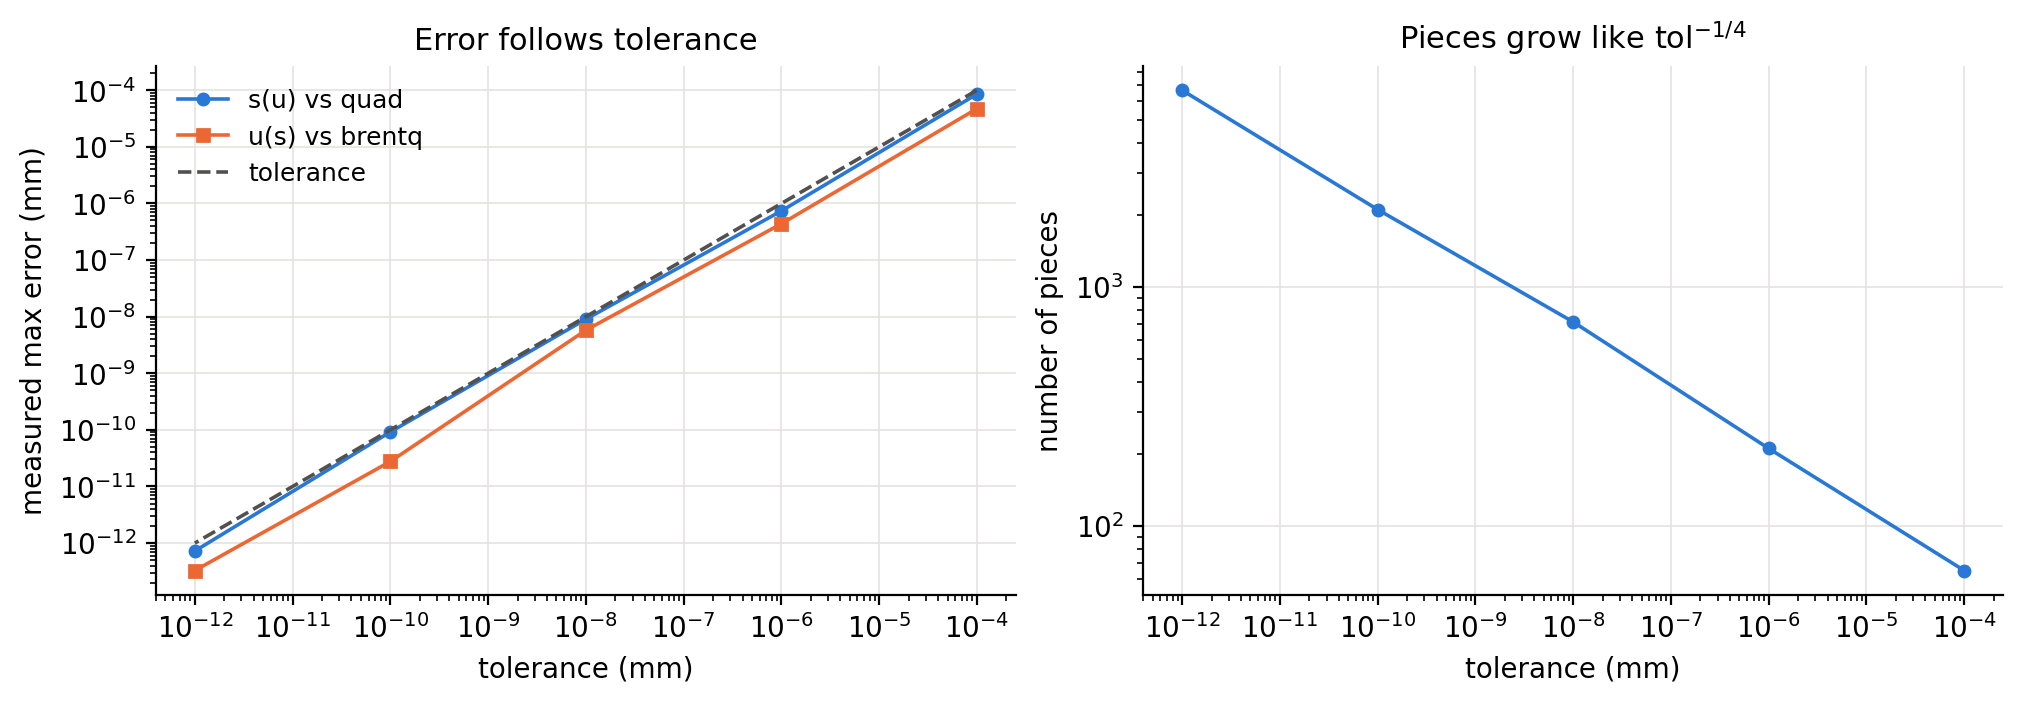

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].loglog(tolerances_sweep, errors_s, "o-", color=plotting.COLORS[0], label="s(u) vs quad")
axes[0].loglog(tolerances_sweep, errors_u, "s-", color=plotting.COLORS[1], label="u(s) vs brentq")
axes[0].loglog(tolerances_sweep, tolerances_sweep, "--", color=plotting.LIMIT, label="tolerance")
axes[0].set(xlabel="tolerance (mm)", ylabel="measured max error (mm)", title="Error follows tolerance")
axes[0].legend()
axes[1].loglog(tolerances_sweep, n_pieces, "o-", color=plotting.COLORS[0])
axes[1].set(xlabel="tolerance (mm)", ylabel="number of pieces", title="Pieces grow like tol$^{-1/4}$")
ratio = np.array(n_pieces[1:]) / np.array(n_pieces[:-1])
print(f"容差每小 100 倍，段数增长倍数：{np.round(ratio, 2)}（四次方误差律预言 ≈ {100**0.25:.2f}）")
assert all(e <= t for e, t in zip(errors_s, tolerances_sweep))
assert all(e <= t for e, t in zip(errors_u, tolerances_sweep))
# 段数按 1/4 次幂增长：实测增长率应在理论值 100^0.25 ≈ 3.16 附近，不离谱也不饱和
assert np.all((2.5 < ratio) & (ratio < 3.5))

实测误差始终压在容差线以下（误差估计偏保守），段数增长完全符合 $O(\text{tol}^{-1/4})$ 的四次方律。
也就是说：把容差收紧到 $10^{-12}$ mm 也只要几千段——精度是"便宜"的，这就是自适应表敢把默认容差
定在 $10^{-8}$ mm 的底气。

**要点：** 弧长表的实测误差跟随容差，且始终低于容差；段数按容差的 $-1/4$ 次幂缓慢增长。

## 5. 进给波动：四种插补方法对比

有了弧长这个翻译官，就可以比较四种插补做法。算例与 docs/数学约定.md 第 5 节一致：
同一条 B 样条、$T_s=1$ ms、峰值进给 100 mm/s 的七段 S 曲线（`seven_phase`，$A=10^3$ mm/s²、$J=2\times10^4$ mm/s³）。

- **Taylor-1 / Taylor-2**（`taylor_interpolate`）：经典参数插补，不做弧长反算，逐周期递推

$$
\dot u=\frac{v}{\lVert\mathbf{C}'\rVert},\qquad
\ddot u=\frac{a}{\lVert\mathbf{C}'\rVert}-\frac{v^2\,\mathbf{C}'\cdot\mathbf{C}''}{\lVert\mathbf{C}'\rVert^4},\qquad
u_{k+1}=u_k+\dot uT_s+\tfrac12\ddot uT_s^2 .
$$

- **弧长表**（`interpolate`）：每个周期查表 $u_k=u(s_k)$，向量化一次完成；
- **进给修正**（`correction_interpolate`）：事先拟合多项式 $\tilde u(s)$（第 7 节），每个周期直接代入。

评价指标是**进给波动**（feedrate fluctuation）：实际步长（相邻插补点的距离）相对指令步长 $\Delta s$ 的偏差
$(\lvert\Delta\mathbf{P}\rvert-\Delta s)/\Delta s$。注意实际步长量的是**弦长**，这一点第 6 节会回来讲。

In [11]:
# 进给轮廓：先加速到 100 mm/s 巡航，再减速到 0（首尾各有一段升降速）
from cnc5x.toolpath import Block

Ts = 0.001
profile = cx.seven_phase(CURVE.length, 0, 0, 100, 1000, 20000)
aligned = cx.align_period(profile, Ts)  # 总时长向上取整为 Ts 的整数倍
t = np.arange(round(aligned.duration / Ts) + 1) * Ts
s_cmd = aligned(t)[0]  # 各周期的指令弧长位置
print(f"总时长 {profile.duration:.3f} s，{len(t) - 1} 个插补周期")


# 整条曲线视为一个 block 的最简刀路（弧长表插补以刀路为对象）
class SingleCurve(cx.ToolPath):
    def __init__(self, curve):
        self.blocks = [Block([curve])]

    def get_v_limit(self, Ts, v_max, a_max, j_max):
        return np.array([0.0, 0.0])


path = SingleCurve(CURVE)

总时长 1.039 s，1039 个插补周期


In [12]:
# 四种方法各跑一遍，统一用 metrics.feedrate_fluctuation 评价
from cnc5x import metrics

u1, points1 = cx.taylor_interpolate(CURVE, profile, Ts, order=1)
u2, points2 = cx.taylor_interpolate(CURVE, profile, Ts, order=2)
points3 = cx.interpolate(path, profile, Ts).position
mapping = cx.feed_correction(CURVE)
u4, points4 = cx.correction_interpolate(CURVE, profile, Ts, mapping)

fluct = {}
for name, pts in [("Taylor-1", points1), ("Taylor-2", points2), ("Arc table", points3), ("Correction", points4)]:
    fluct[name] = metrics.feedrate_fluctuation(pts, s_cmd)

print(f"{'方法':<12} 最大相对波动（去掉首尾 20 个周期）")
for name, f in fluct.items():
    print(f"{name:<12} {np.nanmax(np.abs(f[20:-20])):.6%}")

方法           最大相对波动（去掉首尾 20 个周期）
Taylor-1     4.924761%
Taylor-2     0.080049%
Arc table    0.002434%
Correction   0.002438%


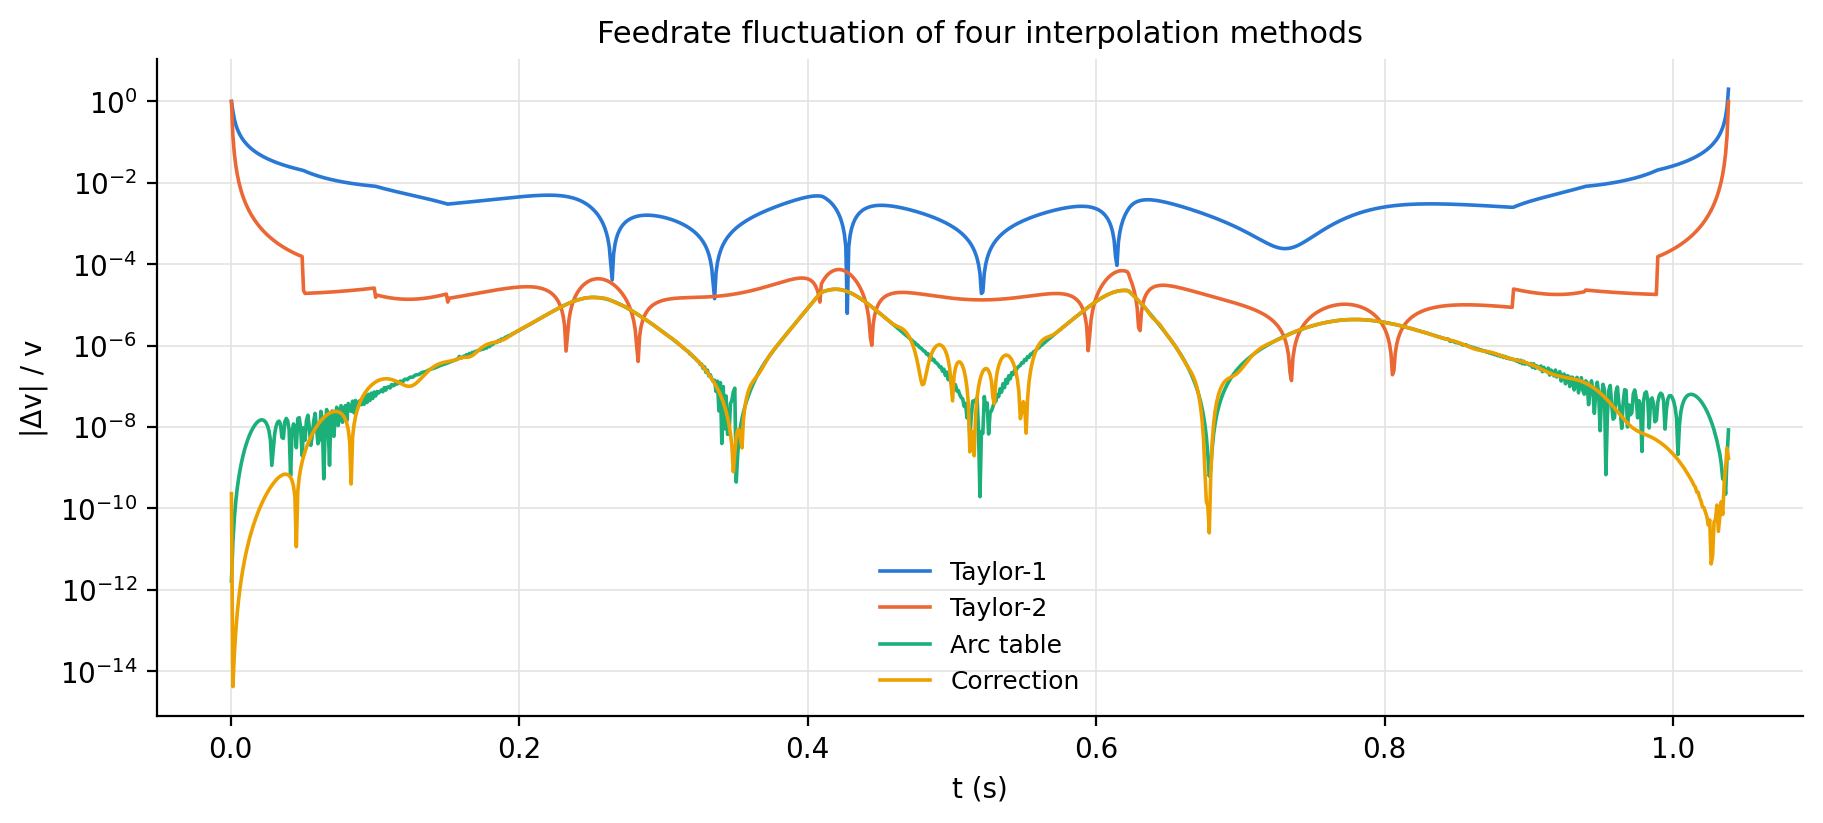

In [13]:
# |Δv|/v 对时间，对数坐标；两端升降速段 Taylor 的截断误差被 a 放大，属于正常现象
t_mid = (t[:-1] + t[1:]) / 2
fig, ax = plt.subplots(figsize=(9, 4))
for name, f in fluct.items():
    ax.semilogy(t_mid, np.abs(f), label=name)
ax.set(xlabel="t (s)", ylabel="|Δv| / v", title="Feedrate fluctuation of four interpolation methods")
ax.legend()

与 docs/数学约定.md 第 5 节的数字对照（同一算例、同一参数）：

| 方法 | 文档给出的波动 | 本节实测 |
|---|---|---|
| Taylor-1 | ≈ 5% | 见上面输出 |
| Taylor-2 | ≈ 0.08% | 见上面输出 |
| 弧长表 / 进给修正 | 都 ≈ 0.0024% | 见上面输出 |

几个观察：

- 一阶 Taylor 的截断误差是 $O(T_s^2)$、二阶是 $O(T_s^3)$，所以两者差约两个数量级；
  升降速段误差最大（公式里 $\ddot u$ 含 $a/\lVert\mathbf{C}'\rVert$ 项，截断它被放大）。
- 弧长表与进给修正的波动**完全相同**，都停在 0.0024% 上下，不再随拟合精度下降——
  这不是方法的误差，而是**指标本身的测量下限**，下一节解释。
- Taylor 的波动还有个隐蔽特征：它是**系统性**的（ $\sigma$ 大的地方总是走过头或走不够），
  不只是噪声。

先断言这些数字，再进入下一节：

In [14]:
# 回归断言：量级与文档一致，且二阶比一阶小一个数量级以上
f1, f2 = (np.nanmax(np.abs(fluct[n][20:-20])) for n in ("Taylor-1", "Taylor-2"))
f3, f4 = (np.nanmax(np.abs(fluct[n][20:-20])) for n in ("Arc table", "Correction"))
assert 0.02 < f1 < 0.10  # Taylor-1 ≈ 5%
assert 4e-4 < f2 < 2e-3  # Taylor-2 ≈ 0.08%
assert f3 < 1e-4 and f4 < 1e-4  # 弧长表、修正 ≈ 0.0024%
assert f1 > 10 * f2

**要点：** 参数插补（Taylor）省掉了弧长反算，代价是进给波动——一阶约 5%，二阶约 0.08%；
弧长表与进给修正都把波动压到 0.0024% 的测量下限。

## 6. 测量下限：弦长总是比弧长短

`feedrate_fluctuation` 用相邻插补点的**直线距离**（弦长 $c$）近似弧长 $\Delta s$。
对曲率 $\kappa$ 的光滑曲线，把 $\mathbf{C}(s)$ 在段中点展开到三阶：端点相对中点的位移是

$$
\pm\frac{\Delta s}{2}\,\hat{\mathbf{t}}+\frac{(\Delta s/2)^2}{2}\,\kappa\,\hat{\mathbf{n}}
\pm\frac{(\Delta s/2)^3}{6}\bigl(-\kappa^2\,\hat{\mathbf{t}}+\kappa_s\,\hat{\mathbf{n}}+\kappa\tau\,\hat{\mathbf{b}}\bigr)+O(\Delta s^4),
$$

两端相减，法向分量（偶数阶）抵消，剩下弦向量
$\Delta\mathbf{c}=\bigl(\Delta s-\kappa^2\tfrac{\Delta s^3}{24}\bigr)\hat{\mathbf{t}}+O(\Delta s^4)$。所以

$$
c=\Delta s\Bigl(1-\frac{\kappa^2\Delta s^2}{24}\Bigr)+O(\Delta s^4)
\qquad\Longrightarrow\qquad
\frac{c-\Delta s}{\Delta s}\approx-\frac{\kappa^2\,(vT_s)^2}{24}.
$$

即使 $u(s)$ 完全精确，这个指标也会报出约 $\kappa^2(vT_s)^2/24$ 的"波动"——而且恒为负（弦比弧短）。
这正是 0.0024% 的来历：巡航段 $v=100$ mm/s、$T_s=1$ ms，$\Delta s=0.1$ mm，取 $\kappa\approx0.07$ mm⁻¹，
得 $\kappa^2\Delta s^2/24\approx2\times10^{-5}$。

数值验证：把弧长表方法的实测波动与理论下限画在一起。

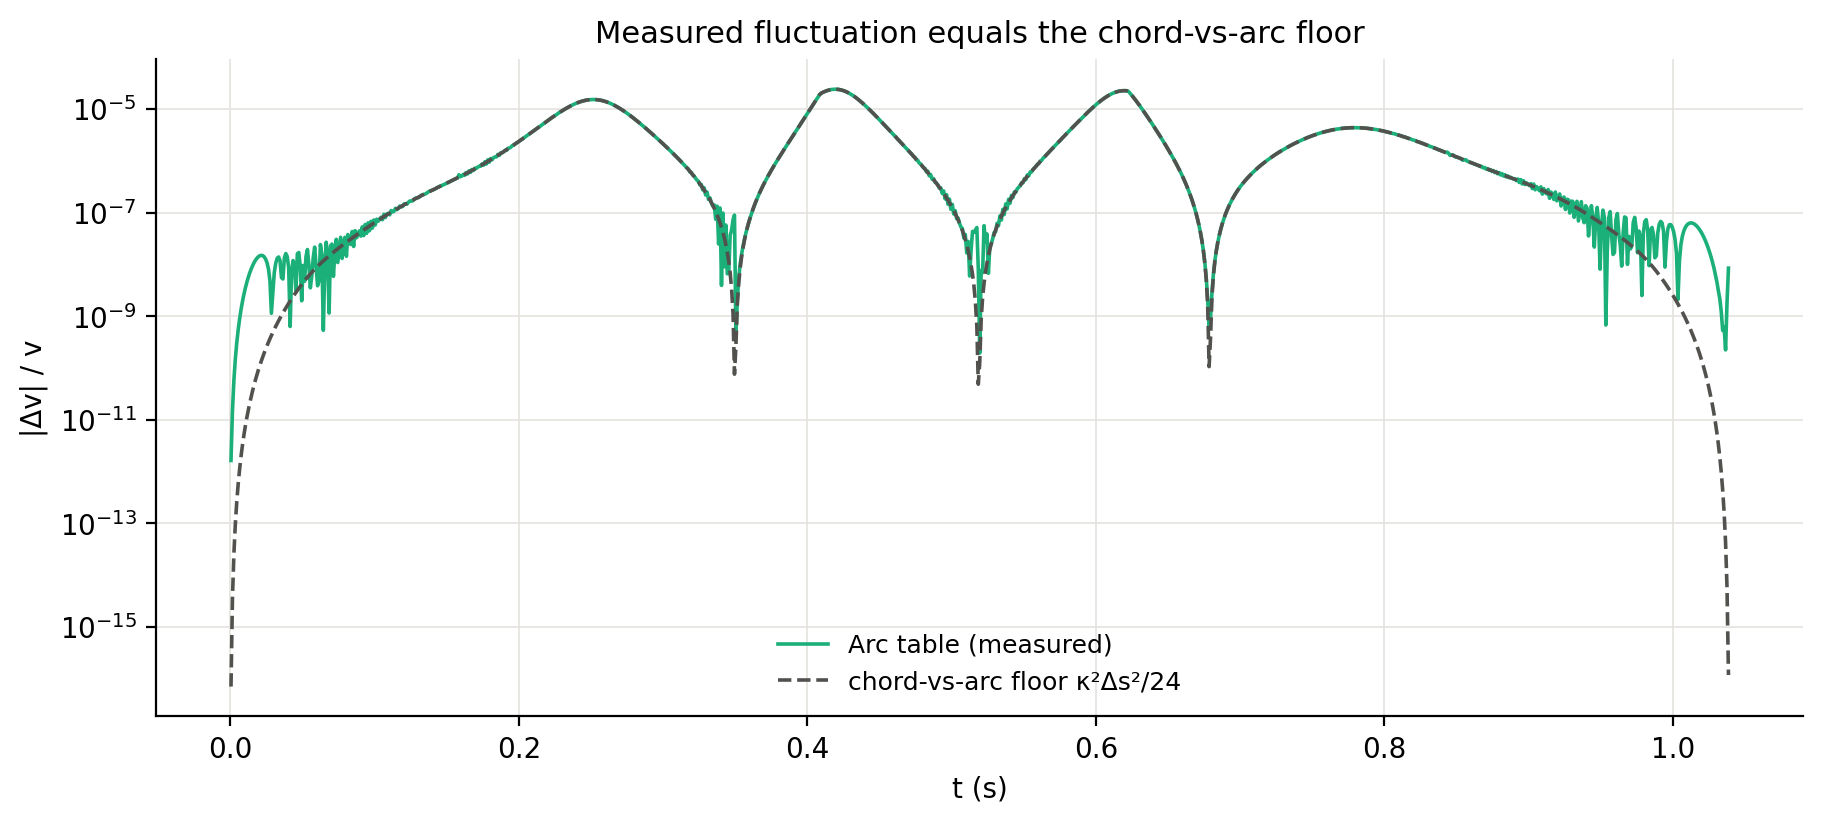

In [15]:
# 理论下限：取每个周期的中点曲率、指令步长 Δs（巡航段 = v·Ts）
kappa_mid = CURVE.curvature(u2[:-1] + np.diff(u2) / 2)  # 用 Taylor-2 的参数近似弧长中点
ds = np.diff(s_cmd)
floor = kappa_mid**2 * ds**2 / 24

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogy(t_mid, np.abs(fluct["Arc table"]), color=plotting.COLORS[2], label="Arc table (measured)")
ax.semilogy(t_mid, floor, "--", color=plotting.LIMIT, label="chord-vs-arc floor κ²Δs²/24")
ax.set(xlabel="t (s)", ylabel="|Δv| / v", title="Measured fluctuation equals the chord-vs-arc floor")
ax.legend()

In [16]:
# 定量对照：实测与理论下限是否重合（曲率接近零的周期里下限不可分辨，略去）
mask = floor[20:-20] > 1e-7
ratio = np.abs(fluct["Arc table"][20:-20])[mask] / floor[20:-20][mask]
print(f"实测波动 / 理论下限：中位数 {np.median(ratio):.4f}")
print(f"理论下限最大值：{floor[20:-20].max():.6%}（≈ 0.0024%，正是文档里的数字）")
assert 0.95 < np.median(ratio) < 1.01  # 中位数贴合理论下限

实测波动 / 理论下限：中位数 0.9999
理论下限最大值：0.002433%（≈ 0.0024%，正是文档里的数字）


两条线几乎完全重合——弧长表方法的"波动"就是弦长近似本身。结论：

- 要分辨比 $\kappa^2(vT_s)^2/24$ 更小的进给误差，这个指标不够用，得直接用弧长表反查 $s$ 再比较；
- 反过来，0.0024% 已经远低于任何机床的机械精度，所以实际使用中这个下限不构成问题。

**要点：** 用弦长测进给，相对偏差自带下限 $\kappa^2(vT_s)^2/24$（恒负）；弧长表与进给修正方法
都已打到这个下限，它们之间的差别用这个指标分不出来。

## 7. 进给修正多项式 `feed_correction`

弧长表插补要维护 $s(u)$、$u(s)$ 两条 Hermite 样条；Erkorkmaz & Altintas 2001（Yuen et al. 2013 沿用）
提出更轻的做法：事先用**分段多项式** $\tilde u(s)$ 逼近弧长的反函数，插补时每个周期只做一次多项式代入
$u_k=\tilde u(s_k)$，不查表、不递推，也没有 Taylor 插补的累积误差。

`fitting.feed_correction` 的做法：

- 在曲线的每个节点区间上，由弧长表取 32 个样本 $(s_k,u_k)$，拟合一条 **9 次 Bézier**；
- 两端的 $u$ 及其对 $s$ 的 1~3 阶导数取**精确值**（由反函数求导 `calculus.inverse_derivatives` 算出），
  10 个系数里 8 个被端点条件定死，最小二乘只决定中间 2 个；段间自动 $C^3$ 连续；
- 拟合后检查段内的**进给误差**

$$
\Bigl|\sigma(\tilde u)\,\tilde u_s-1\Bigr|\le10^{-6}
$$

  （链式法则：实际进给 $=\mathrm{d}s/\mathrm{d}t=\sigma(\tilde u)\,\tilde u_s\cdot v_{\text{指令}}$，
  所以这个量就是实际进给与指令进给之比减 1）以及单调性 $\tilde u_s>0$；不合格的段对半分重拟合。

修正多项式：29 段 9 次 Bézier，参数域 [0, 88.8811]（= 弧长）
最大进给误差：7.81e-07（容差 1e-6）；min ũ_s = 0.0041 > 0


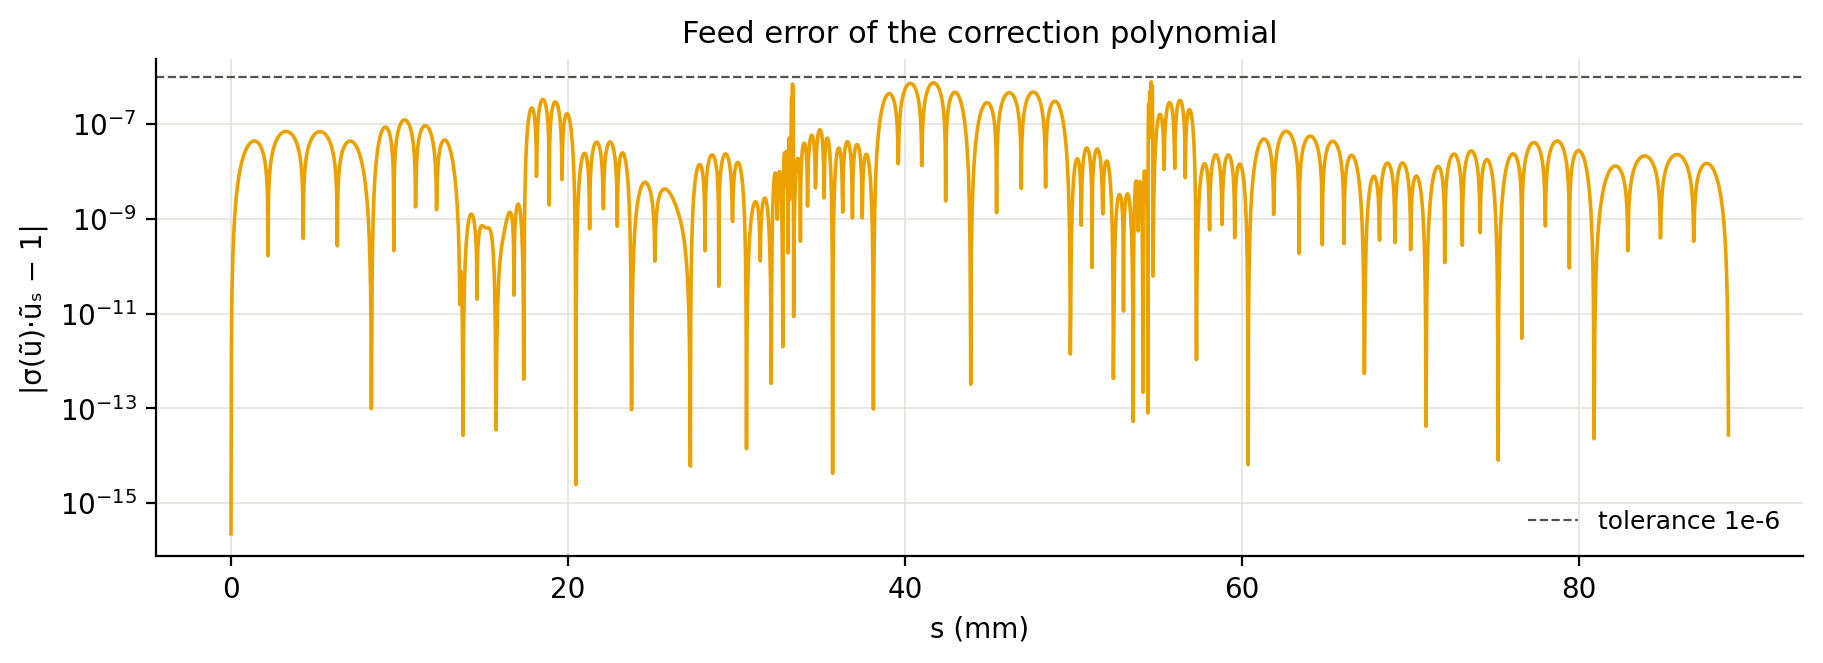

In [17]:
# 拟合结果：分段数与端点处的进给误差
print(f"修正多项式：{len(mapping.breaks) - 1} 段 9 次 Bézier，参数域 [0, {mapping.domain[1]:.4f}]（= 弧长）")

s_dense = np.linspace(0, mapping.domain[1], 4001)
u_fit = mapping(s_dense)[:, 0]
u_s = mapping(s_dense, 1)[:, 0]
feed_error = np.abs(CURVE.speed(u_fit) * u_s - 1)

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.semilogy(s_dense, feed_error, color=plotting.COLORS[3])
ax.axhline(1e-6, color=plotting.LIMIT, ls="--", lw=0.8, label="tolerance 1e-6")
ax.set(xlabel="s (mm)", ylabel="|σ(ũ)·ũₛ − 1|", title="Feed error of the correction polynomial")
ax.legend()
print(f"最大进给误差：{feed_error.max():.2e}（容差 1e-6）；min ũ_s = {u_s.min():.4f} > 0")
assert feed_error.max() <= 1e-6 and u_s.min() > 0

整条曲线上的进给误差都被压在 $10^{-6}$ 以内——比第 6 节的测量下限小一个数量级以上，
所以第 5 节里它与弧长表方法的波动一模一样：不是它不够好，是尺子到极限了。

与弧长表的分工：**弧长表**是通用基础设施（求弧长、等弧长采样、刀路按弧长求导都靠它）；
**进给修正多项式**是为实时插补优化的专用映射，每个周期只有一次多项式求值，拟合误差还由
$10^{-6}$ 的容差直接保证。

**要点：** 进给修正多项式 = 每跨度一条 9 次 Bézier 拟合 $u(s)$，端点 $C^3$ 精确衔接，
进给误差 $\lvert\sigma(\tilde u)\tilde u_s-1\rvert\le10^{-6}$，插补时只是代入。

## 8. 练习

1. **$T_s$ 减半会怎样？** 把 `Ts` 改成 0.0005 重跑第 5 节。Taylor-1 的波动应降到约 1/4（$O(T_s^2)$），
   Taylor-2 降到约 1/8；弧长表与进给修正呢？提示：下限 $\kappa^2(vT_s)^2/24$ 也随 $T_s^2$ 下降，
   想想为什么实测仍然"跟着降"。
2. **更弯的曲线。** 把控制点 `[25, -10]` 改成 `[25, -25]`（曲率峰值变大），重跑第 5、6 节，
   观察测量下限按 $\kappa^2$ 上移。再用第 6 节的公式预言新的下限值并验证。
3. **弧长表拒绝什么曲线？** 构造一条有驻点的曲线（例如 `Bezier([[0,0],[1,0],[0,0],[1,0]])`
   在中点附近速度接近零），尝试建 `ArcLengthTable`，观察报错信息；对照 `curves.py` 中
   `_piece_errors` 的"速度为零"检查，说明为什么驻点曲线不能用弧长参数化。
4. **修正多项式的自由度。** 9 次 Bézier 有 10 个系数，端点 $C^3$ 条件定死 8 个。把
   `feed_correction(CURVE, degree=7)` 跑一遍（端点条件恰好定死全部系数，没有最小二乘自由度），
   看它需要分多少段才能让进给误差达标，与 9 次的结果比较段数。

## 延伸阅读

- [docs/数学约定.md](../docs/数学约定.md) 第 2 节（弧长表与反函数求导）、第 5 节（三种插补与进给波动的数字）；
- [docs/路线图.md](../docs/路线图.md)；
- Erkorkmaz & Altintas 2001（进给修正多项式的原始文献）；Yuen et al. 2013（9 次 $C^3$ 的取法）；
- 源码：`cnc5x/curves.py`（`ArcLengthTable`、`_piece_errors`）、`cnc5x/fitting.py`（`feed_correction`）、
  `cnc5x/interpolator.py`、`cnc5x/metrics.py`（`feedrate_fluctuation`）。